In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone



In [19]:
def cross_validation_kfold_reg(X, y, modelo_base, grid_parametros, k=5, nombre_modelo=""):
    X_arr = np.array(X)
    y_arr = np.array(y)
    indices = np.arange(len(X_arr))
    np.random.shuffle(indices)
    bloques_indices = np.array_split(indices, k)
    
    gamma_opt = None
    menor_error_medio = float('inf')
    
    print(f"\n--- Iniciando K-FOLD (k={k}) | Caso: {nombre_modelo} ---")
    
    for gamma in grid_parametros:
        print(f"\nEvaluando \u03B3: {gamma}")
        errores_k = []
        modelo_gamma = clone(modelo_base)
        modelo_gamma.set_params(**gamma)
        
        for i in range(k):
            idx_test = bloques_indices[i]
            idx_train = np.hstack([bloques_indices[j] for j in range(k) if j != i])
            
            modelo_gamma.fit(X_arr[idx_train], y_arr[idx_train])
            predicciones = modelo_gamma.predict(X_arr[idx_test])
            
            error_i = mean_squared_error(y_arr[idx_test], predicciones)
            errores_k.append(error_i)
            print(f"   -> Pliegue {i+1} | MSE: {error_i:.4f}")
        
        error_medio_gamma = np.mean(errores_k)
        print(f" => MSE medio E(\u03B3) = {error_medio_gamma:.4f}")
        
        if error_medio_gamma < menor_error_medio:
            menor_error_medio = error_medio_gamma
            gamma_opt = gamma
            
    print(f">>> \u03B3_opt elegido: {gamma_opt} (MSE mínimo: {menor_error_medio:.4f}) <<<")
    
    modelo_final = clone(modelo_base)
    modelo_final.set_params(**gamma_opt)
    modelo_final.fit(X_arr, y_arr)
    return modelo_final, gamma_opt, menor_error_medio


def leave_one_out_reg(X, y, modelo_base, grid_parametros, nombre_modelo=""):
    X_arr = np.array(X)
    y_arr = np.array(y)
    n = len(X_arr)
    
    gamma_opt = None
    menor_error_medio = float('inf')
    
    print(f"\n--- Iniciando LEAVE-ONE-OUT (n={n}) | Caso: {nombre_modelo} ---")
    
    for gamma in grid_parametros:
        print(f"Evaluando \u03B3: {gamma} ... ", end="")
        errores_n = []
        modelo_gamma = clone(modelo_base)
        modelo_gamma.set_params(**gamma)
        
        for i in range(n):
            X_test, y_test = X_arr[i:i+1], y_arr[i:i+1]
            X_train = np.delete(X_arr, i, axis=0)
            y_train = np.delete(y_arr, i, axis=0)
            
            modelo_gamma.fit(X_train, y_train)
            pred = modelo_gamma.predict(X_test)
            
            error_i = mean_squared_error(y_test, pred)
            errores_n.append(error_i)
        
        error_medio_gamma = np.mean(errores_n)
        print(f"MSE medio = {error_medio_gamma:.4f}")
        
        if error_medio_gamma < menor_error_medio:
            menor_error_medio = error_medio_gamma
            gamma_opt = gamma
            
    print(f">>> \u03B3_opt elegido: {gamma_opt} (MSE mínimo: {menor_error_medio:.4f}) <<<")
    
    modelo_final = clone(modelo_base)
    modelo_final.set_params(**gamma_opt)
    modelo_final.fit(X_arr, y_arr)
    return modelo_final, gamma_opt, menor_error_medio

--- 1. Carga, EDA y Limpieza ---
Dimensiones después de limpieza: (66, 9)

--- Características seleccionadas (Top 5): ['PointsAjust', 'PointsNonAdjust', 'Adjustment', 'Transactions', 'Length']


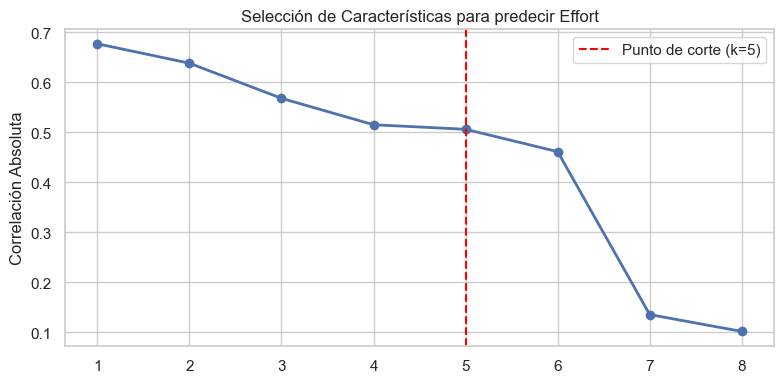

In [20]:


# =============================================================================
# 1. CARGA DE DATOS, EDA Y LIMPIEZA
# =============================================================================
print("--- 1. Carga, EDA y Limpieza ---")
ruta = "fp.csv"
df = pd.read_csv(ruta)

columnas_a_eliminar = ['id', 'Project', 'YearEnd', 'Language']
df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns], inplace=True)

target = 'Effort' 
features = [col for col in df.columns if col != target]

# Rellenar nulos con la mediana
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Limpieza de Outliers (IQR)
df_clean = df.copy()
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5 * IQR) & (df_clean[col] <= Q3 + 1.5 * IQR)]

print(f"Dimensiones después de limpieza: {df_clean.shape}")

# =============================================================================
# 2. Y 3. PARTICIÓN (70/30) Y ESCALADO (X e y)
# =============================================================================
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar X
scaler_X = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), columns=features, index=X_test.index)

# Escalar y
scaler_y = StandardScaler()
y_train_scaled = pd.Series(scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index)
y_test_scaled = pd.Series(scaler_y.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)

# =============================================================================
# 4. SELECCIÓN DE CARACTERÍSTICAS
# =============================================================================
corr_matrix_train = X_train_scaled.assign(**{target: y_train_scaled}).corr()
corr_target = corr_matrix_train[target].abs().sort_values(ascending=False).drop(target)

diferencias = np.diff(corr_target.values)
punto_corte = np.argmax(diferencias) + 2 
top_features = corr_target.index[:punto_corte].tolist()

print(f"\n--- Características seleccionadas (Top {punto_corte}):", top_features)

# Gráfica del codo
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(corr_target)+1), corr_target.values, 'bo-', linewidth=2)
plt.axvline(x=punto_corte, color='red', linestyle='--', label=f'Punto de corte (k={punto_corte})')
plt.title(f'Selección de Características para predecir {target}')
plt.ylabel('Correlación Absoluta')
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# 5. CONJUNTOS TIPO 'A' (TODAS) Y 'B' (MEJORES)
# =============================================================================
X_train_all = X_train_scaled
X_test_all = X_test_scaled

X_train_best = X_train_scaled[top_features]
X_test_best = X_test_scaled[top_features]

# =============================================================================
# 6. ENTRENAMIENTO Y OPTIMIZACIÓN (EN EL 70% DE TRAIN)
# =============================================================================
dt_base = DecisionTreeRegressor(random_state=42)
rf_base = RandomForestRegressor(random_state=42)
lr_base = LinearRegression()

grid_dt = [{'max_depth': 3}, {'max_depth': 5}, {'max_depth': 10}, {'max_depth': None}]
grid_rf = [{'n_estimators': 10, 'max_depth': 5}, {'n_estimators': 50, 'max_depth': 10}]
grid_lr = [{}] 

modelos_finales = {}




 ENTRENANDO MODELOS A (Todas) y B (Mejores) con K-Fold (k=5)

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 1.4487
   -> Pliegue 2 | MSE: 0.2718
   -> Pliegue 3 | MSE: 2.0943
   -> Pliegue 4 | MSE: 1.9602
   -> Pliegue 5 | MSE: 1.4192
 => MSE medio E(γ) = 1.4388

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 2.4357
   -> Pliegue 2 | MSE: 0.3553
   -> Pliegue 3 | MSE: 2.0249
   -> Pliegue 4 | MSE: 1.7197
   -> Pliegue 5 | MSE: 1.6301
 => MSE medio E(γ) = 1.6331

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 3.2764
   -> Pliegue 2 | MSE: 0.3931
   -> Pliegue 3 | MSE: 1.7601
   -> Pliegue 4 | MSE: 1.7616
   -> Pliegue 5 | MSE: 1.5310
 => MSE medio E(γ) = 1.7444

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 3.2764
   -> Pliegue 2 | MSE: 0.3931
   -> Pliegue 3 | MSE: 1.7601
   -> Pliegue 4 | MSE: 1.7616
   -> Pliegue 5 | MSE: 1.8195
 => MSE medio E(γ) = 1.8021
>>> γ_opt elegido: {'max_depth': 3} (MSE mínimo: 1.4388) 

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\val

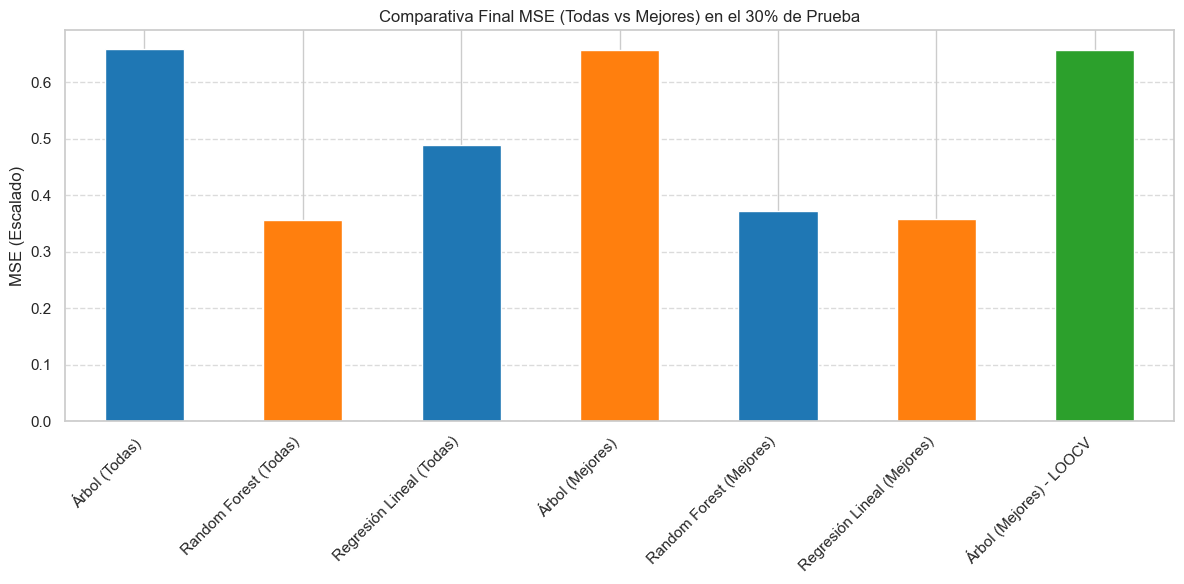

In [21]:
print("\n" + "="*70)
print(" ENTRENANDO MODELOS A (Todas) y B (Mejores) con K-Fold (k=5)")
print("="*70)

# --- MODELOS A (Todas las variables) ---
dt_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, dt_base, grid_dt, k=5)
rf_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, rf_base, grid_rf, k=5)
lr_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, lr_base, grid_lr, k=5)

modelos_finales['Árbol (Todas)'] = (dt_all, 'all')
modelos_finales['Random Forest (Todas)'] = (rf_all, 'all')
modelos_finales['Regresión Lineal (Todas)'] = (lr_all, 'all')

# --- MODELOS B (Mejores variables) ---
dt_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, dt_base, grid_dt, k=5)
rf_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, rf_base, grid_rf, k=5)
lr_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, lr_base, grid_lr, k=5)

modelos_finales['Árbol (Mejores)'] = (dt_best, 'best')
modelos_finales['Random Forest (Mejores)'] = (rf_best, 'best')
modelos_finales['Regresión Lineal (Mejores)'] = (lr_best, 'best')


print("\n" + "="*70)
print(" ENTRENANDO CON LEAVE-ONE-OUT (Muestra rápida para no colgar la PC)")
print("="*70)
# Muestra de 300 para que LOOCV acabe hoy antes de las 11:59 pm
n_muestras_loo = min(300, len(X_train_all))
indices_loo = np.random.choice(len(X_train_all), n_muestras_loo, replace=False)

# Aplicando LOO solo al modelo ganador de los árboles (como ejemplo para cumplir el requisito)
print("[Árbol B - LOOCV] Procesando...")
dt_loo, param_dt_loo, mse_dt_loo = leave_one_out_reg(X_train_best.iloc[indices_loo], y_train_scaled.iloc[indices_loo], dt_base, grid_dt)
modelos_finales['Árbol (Mejores) - LOOCV'] = (dt_loo, 'best')


# =============================================================================
# 7. EVALUACIÓN FINAL EN CONJUNTO DE PRUEBAS (30% TEST SET)
# =============================================================================
print("\n" + "="*70)
print(" EVALUACIÓN FINAL EN CONJUNTO DE PRUEBAS (30%)")
print("="*70)

resultados = {}

for nombre, (modelo, tipo_datos) in modelos_finales.items():
    X_test_eval = X_test_all if tipo_datos == 'all' else X_test_best
    y_pred_scaled = modelo.predict(X_test_eval)
    
    resultados[nombre] = {
        'MSE': mean_squared_error(y_test_scaled, y_pred_scaled),
        'MAE': mean_absolute_error(y_test_scaled, y_pred_scaled),
        'R2': r2_score(y_test_scaled, y_pred_scaled)
    }

df_resultados = pd.DataFrame(resultados).T
print(df_resultados.round(4))

# Gráfica Comparativa Final
plt.figure(figsize=(12, 6))
df_resultados['MSE'].plot(kind='bar', color=['#1f77b4', '#ff7f0e']*3 + ['#2ca02c'])
plt.title('Comparativa Final MSE (Todas vs Mejores) en el 30% de Prueba')
plt.ylabel('MSE (Escalado)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()